# Análisis de Datos de Viviendas

### Carga de Datos
Cargamos el dataset `housing.csv` en un DataFrame de pandas para iniciar el análisis.

In [ ]:
import pandas as pd
datos = pd.read_csv("housing.csv")

Las primeras 5 filas del DataFrame

### Visualización Inicial de Precios de Viviendas
Este gráfico de dispersión muestra la distribución geográfica de las propiedades, coloreadas por el valor medio de las viviendas (`median_house_value`).

In [ ]:
datos.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<Axes: xlabel='latitude', ylabel='longitude'>

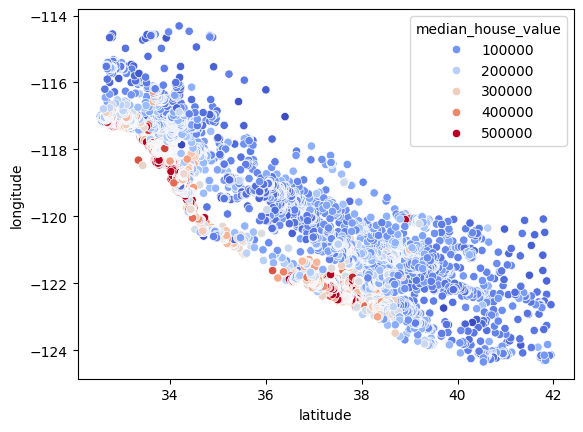

In [ ]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_house_value",
               palette="coolwarm")

### Visualización del Ingreso Medio por Ubicación
Este gráfico representa la distribución geográfica de los hogares, utilizando el ingreso medio (`median_income`) para colorear los puntos y el tamaño del punto para indicar el nivel de ingreso.

TypeError: cannot convert the series to <class 'float'>

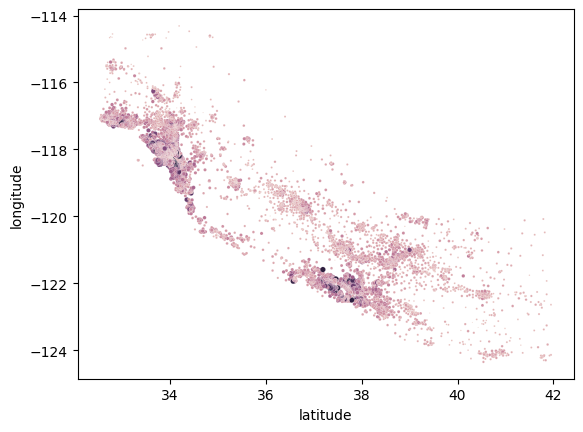

In [ ]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=datos, hue="median_income",
               s=datos["median_income"])

### Preparación de Datos para K-Means
Seleccionamos las columnas de `latitude`, `longitude` y `median_income` para ser utilizadas en el algoritmo de clustering K-Means. Estas características definirán los segmentos económicos.

In [ ]:
datos.loc[:, ["latitude", "longitude", "median_income"]]

,latitude,longitude,median_income
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


### Aplicación del Algoritmo K-Means
Utilizamos K-Means con 6 clusters para agrupar los datos en segmentos basados en la ubicación y el ingreso medio. `fit_predict` entrena el modelo y asigna cada punto a un cluster.

In [ ]:
from sklearn.cluster import KMeans
x = datos.loc[:, ["latitude", "longitude", "median_income"]]
modelo = KMeans(n_clusters=6)
predicciones = modelo.fit_predict(x)

### Verificación de la Forma de las Predicciones
Se comprueba la forma del array `predicciones` para asegurar que el número de asignaciones de clusters coincide con el número de filas en el DataFrame original.

In [ ]:
predicciones.shape

(20640,)

### Añadiendo el Segmento Económico al DataFrame
Se añade una nueva columna `segmento_economico` al DataFrame `x` con las asignaciones de clusters obtenidas de K-Means.

In [ ]:
x["segmento_economico"] = predicciones

### DataFrame con Segmento Económico
Se muestra el DataFrame `x` incluyendo la nueva columna `segmento_economico`.

In [ ]:
x

,latitude,longitude,median_income,segmento_economico
0,37.88,-122.23,8.3252,2
1,37.86,-122.22,8.3014,2
2,37.85,-122.24,7.2574,2
3,37.85,-122.25,5.6431,2
4,37.85,-122.25,3.8462,3
...,...,...,...,...
20635,39.48,-121.09,1.5603,3
20636,39.49,-121.21,2.5568,3
20637,39.43,-121.22,1.7000,3
20638,39.43,-121.32,1.8672,3


### Distribución de Hogares por Segmento Económico
Este cálculo muestra el número de hogares asignados a cada uno de los 6 segmentos económicos identificados por K-Means, lo que nos da una idea del tamaño de cada cluster.

In [ ]:
x["segmento_economico"].value_counts()

,count
segmento_economico,
5,6620
3,4875
0,4162
2,2771
1,1677
4,535


### Visualización de Segmentos Económicos Geográficamente
Este gráfico de dispersión muestra la distribución geográfica de los hogares, coloreados por su `segmento_economico` asignado, utilizando una paleta de colores para diferenciar los clusters.

<Axes: xlabel='latitude', ylabel='longitude'>

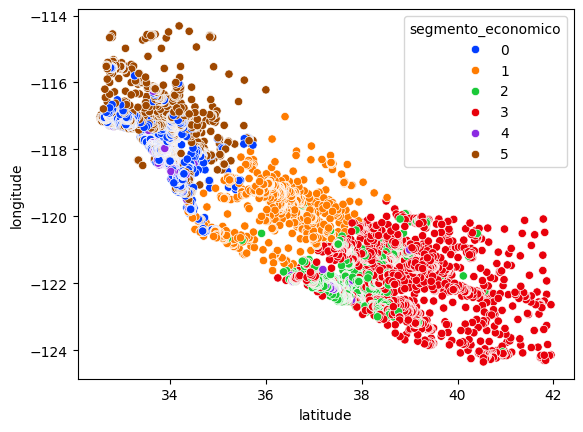

In [ ]:
import seaborn as sb
sb.scatterplot(x="latitude", y="longitude", data=x, hue="segmento_economico",
               palette="bright")

### Recuento de Hogares por Segmento Económico
Este gráfico de barras visualiza el número total de hogares en cada `segmento_economico`, ofreciendo una representación clara de la distribución de los clusters.

<Axes: xlabel='segmento_economico', ylabel='count'>

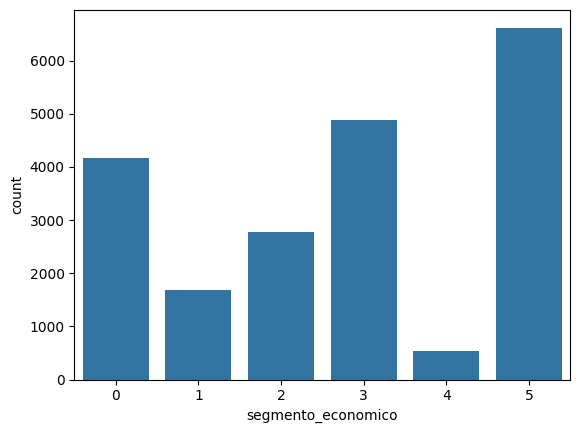

In [ ]:
sb.countplot(x="segmento_economico", data=x)

### Análisis del Ingreso Medio por Segmento Económico
Calculamos el ingreso medio para cada uno de los 6 `segmento_economico` para entender las características económicas distintivas de cada cluster.

In [ ]:
x.groupby(["segmento_economico"])["median_income"].mean()

,median_income
segmento_economico,
0,5.332638
1,2.660862
2,5.518715
3,2.822327
4,10.563325
5,2.799299
